In [1]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.neural_network import MLPRegressor
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
import numpy as np
import random
import pandas as pd
import optuna
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
# Settings for repeatability
# Guarantee that the results and data splits will be identical every time you run them
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.RandomState(SEED)
KF = KFold(n_splits=10, shuffle=True, random_state=SEED)
TRIALS = 50

# RVFL Implementation

In [3]:
class RVFL(BaseEstimator, RegressorMixin):
    # BaseEstimator and RegressorMixin provide compatibility with Pipeline and cross_val_score, among others
    def __init__(self, n_hidden=100, activation='relu', random_state=None, alpha=0.01,
                 direct_linkage=True, scale = 1.0, l1_ratio=0.5, solver='ridge',
                 weight_distribution='uniform', bias_scale = 1.0):
        self.n_hidden = n_hidden
        self.activation = activation
        self.random_state = random_state
        self.alpha = alpha
        self.direct_linkage = direct_linkage
        self.scale = scale
        self.l1_ratio = l1_ratio
        self.solver = solver
        self.weight_distribution = weight_distribution
        self.bias_scale = bias_scale
        # There are no operations, only argument assignments, according to scikit-learn rules

    def fit(self, X, y):
        # check_X_y checks data types, format and missing values
        X,y = check_X_y(X, y)
        self.n_features_in_ = X.shape[1]
        rng = np.random.RandomState(self.random_state)

        # Randomize input weights and biases
        if self.weight_distribution == 'uniform':
            W = rng.uniform(-self.scale, self.scale, size=(self.n_features_in_, self.n_hidden))
            b = rng.uniform(-self.bias_scale, self.bias_scale, size=(self.n_hidden,))
        else:
            W = rng.normal(loc=0.0, scale=self.scale, size=(self.n_features_in_, self.n_hidden))
            b = rng.normal(loc=0.0, scale=self.bias_scale, size=(self.n_hidden,))

        hidden_layer = np.dot(X, W) + b

        # Nonlinear activation function
        if self.activation == 'relu':
          hidden_layer = np.maximum(0, hidden_layer)
        elif self.activation == 'sigmoid':
          hidden_layer = 1 / (1 + np.exp(-hidden_layer))
        elif self.activation == 'tanh':
          hidden_layer = np.tanh(hidden_layer)

        # Direct linkage
        if self.direct_linkage:
            H_train = np.hstack([X, hidden_layer])
        else:
            H_train = hidden_layer

        # Regularization
        if self.solver == 'ridge':
            reg = Ridge(alpha=self.alpha)
            reg.fit(H_train, y)
            self.solver_ = reg

        elif self.solver == 'elasticnet':
            reg = ElasticNet(
                alpha=self.alpha,
                l1_ratio=self.l1_ratio,
                max_iter=50000,
                tol=1e-3)
            reg.fit(H_train, y)
            self.solver_ = reg

        # Learned Attributes
        self.W_ = W
        self.b_ = b
        return self

    def predict(self, X_test):
        # Verification if the model passed the fit method before prediction
        check_is_fitted(self, ['W_', 'b_', 'solver_'])
        X = check_array(X_test)

        hidden_layer_test = np.dot(X, self.W_) + self.b_

        if self.activation == 'relu':
          hidden_layer_test = np.maximum(0, hidden_layer_test)
        elif self.activation == 'sigmoid':
            hidden_layer_test = 1 / (1 + np.exp(-hidden_layer_test))
        elif self.activation == 'tanh':
            hidden_layer_test = np.tanh(hidden_layer_test)

        if self.direct_linkage:
            H_test = np.hstack([X, hidden_layer_test])
        else:
            H_test = hidden_layer_test

        return self.solver_.predict(H_test)

# Preprocessing

In [4]:
test_features = pd.read_csv('spectral_test_features.csv')
train = pd.read_csv('spectral_train.csv')

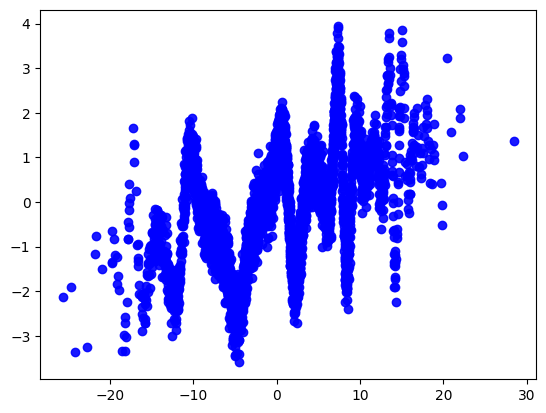

In [52]:
plt.scatter(train['X'], train['y'], color='blue', alpha=0.9)
plt.show()

In [7]:
X = train.drop('y', axis=1).values
y = train['y'].values

X_train, X_held_out, y_train, y_held_out = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [8]:
print("X_train shape", X_train.shape)
print("X_held_out shape", X_held_out.shape)

X_train shape (4000, 1)
X_held_out shape (1000, 1)


# Hyperparameter tuning

In [9]:
def objective_with_pruning(trial):
    # Hyperparameter search space
    n_hidden = trial.suggest_int('n_hidden', 10, 2500)
    activation = trial.suggest_categorical('activation', ['relu', 'sigmoid', 'tanh'])
    scale = trial.suggest_float('scale', 0.01, 10.0, log=True)
    direct_linkage = trial.suggest_categorical('direct_linkage', [True, False])
    weight_distribution = trial.suggest_categorical('weight_distribution', ['uniform', 'normal'])
    bias_scale = trial.suggest_float('bias_scale', 1e-4, 1.0, log=True)
    alpha = trial.suggest_float('alpha', 1e-5, 100, log=True)

    model = RVFL(
        n_hidden=n_hidden,
        activation=activation,
        random_state=SEED,
        alpha=alpha,
        direct_linkage=direct_linkage,
        scale=scale,
        weight_distribution=weight_distribution,
        bias_scale=bias_scale,
        solver = 'ridge'
    )

    # Using Pipeline ensures that the scaler is trained only on the training set from each fold, preventing data leakage
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rvfl', model)
    ])
    scores = []

    for step, (train_idx, val_idx) in enumerate(KF.split(X_train)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)

        mse = mean_squared_error(y_fold_val, preds)
        scores.append(mse)

        current_mean_mse = np.mean(scores)
        trial.report(current_mean_mse, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

In [10]:
study_rvfl = optuna.create_study(
    study_name="study_rvfl",
    storage="sqlite:///projekt3.db",
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_rvfl.optimize(objective_with_pruning, n_trials=TRIALS)

[I 2026-06-22 16:02:44,894] A new study created in RDB with name: study_rvfl
[I 2026-06-22 16:02:46,968] Trial 0 finished with value: 0.8846249791614783 and parameters: {'n_hidden': 1744, 'activation': 'tanh', 'scale': 1.4401472828461634, 'direct_linkage': False, 'weight_distribution': 'uniform', 'bias_scale': 0.00370228692069884, 'alpha': 0.002524911224859439}. Best is trial 0 with value: 0.8846249791614783.
[I 2026-06-22 16:02:48,907] Trial 1 finished with value: 0.9867754554733199 and parameters: {'n_hidden': 1826, 'activation': 'relu', 'scale': 1.6367645761140062, 'direct_linkage': True, 'weight_distribution': 'normal', 'bias_scale': 0.03448290408913142, 'alpha': 8.831257714012064}. Best is trial 0 with value: 0.8846249791614783.
[I 2026-06-22 16:02:51,198] Trial 2 finished with value: 1.209423779303465 and parameters: {'n_hidden': 1814, 'activation': 'sigmoid', 'scale': 0.1217211275847546, 'direct_linkage': False, 'weight_distribution': 'uniform', 'bias_scale': 0.00543006077921949

In [11]:
pruned = [t for t in study_rvfl.trials
          if t.state == optuna.trial.TrialState.PRUNED]
complete = [t for t in study_rvfl.trials
            if t.state == optuna.trial.TrialState.COMPLETE]

print(f"Completed: {len(complete)}, rejected (pruned): {len(pruned)}")
print("Best result:", study_rvfl.best_value)
print("Best parameters:", study_rvfl.best_params)

Completed: 35, rejected (pruned): 15
Best result: 0.14919918959440476
Best parameters: {'n_hidden': 1893, 'activation': 'relu', 'scale': 0.1520065636523068, 'direct_linkage': False, 'weight_distribution': 'uniform', 'bias_scale': 0.2762085826928693, 'alpha': 0.0003815322501060946}


In [12]:
best_params_rvfl = study_rvfl.best_params.copy()

best_params_rvfl['solver'] = 'ridge'
best_model_rvfl = RVFL(random_state=SEED, **best_params_rvfl)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rvfl', best_model_rvfl)
])

pipeline.fit(X_train, y_train)
predictions_held_out = pipeline.predict(X_held_out)

In [13]:
mse_rvfl = mean_squared_error(y_held_out, predictions_held_out)
mae_rvfl = mean_absolute_error(y_held_out, predictions_held_out)
print("MSE:", mse_rvfl)
print("RMSE", np.sqrt(mse_rvfl))
print("MAE", mae_rvfl)
print("R^2", r2_score(y_held_out, predictions_held_out))

MSE: 0.14069383726037732
RMSE 0.37509177178442255
MAE 0.2939628726486693
R^2 0.91585090263611


# MLP

In [14]:
def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 2, 5)
    layers = []
    for i in range(n_layers):
        n_units = trial.suggest_int(f'n_units_l{i}', 10, 300)
        layers.append(n_units)

    hidden_layer_sizes = tuple(layers)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    # solver = trial.suggest_categorical('solver',['sgd', 'adam'])
    # Skipping the solver search. 'lbfgs' is too slow for large data and does not
    # support early_stopping. 'sgd' would force the addition of hyperparameters, and 'adam' is optimal
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-3, 1e-2, log=True)
    n_iter_no_change = trial.suggest_int('n_iter_no_change', 10, 50)

    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        n_iter_no_change=n_iter_no_change,
        solver="adam",
        early_stopping=True, # Set to speed up learning
        random_state=SEED,
        max_iter=1000,
        tol=1e-3 # Looser tolerance speeds up single trial convergence
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', model)
    ])
    scores = []

    for step, (train_idx, val_idx) in enumerate(KF.split(X_train)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)

        mse = mean_squared_error(y_fold_val, preds)
        scores.append(mse)

        current_mean_mse = np.mean(scores)
        trial.report(current_mean_mse, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

In [15]:
study_mlp = optuna.create_study(
    study_name="study_mlp",
    storage="sqlite:///projekt3.db",
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_mlp.optimize(objective_mlp, n_trials=TRIALS)

[I 2026-06-22 16:05:49,032] A new study created in RDB with name: study_mlp
[I 2026-06-22 16:09:41,640] Trial 0 finished with value: 0.403025834180511 and parameters: {'n_layers': 4, 'n_units_l0': 93, 'n_units_l1': 76, 'n_units_l2': 170, 'n_units_l3': 219, 'activation': 'tanh', 'alpha': 0.005486797781181633, 'learning_rate_init': 0.0030264388373336944, 'n_iter_no_change': 26}. Best is trial 0 with value: 0.403025834180511.
[I 2026-06-22 16:10:56,477] Trial 1 finished with value: 0.4412028017802573 and parameters: {'n_layers': 3, 'n_units_l0': 222, 'n_units_l1': 137, 'n_units_l2': 27, 'activation': 'tanh', 'alpha': 5.3699089471963626e-05, 'learning_rate_init': 0.0014977928606210794, 'n_iter_no_change': 31}. Best is trial 0 with value: 0.403025834180511.
[I 2026-06-22 16:14:39,538] Trial 2 finished with value: 0.20942609966777237 and parameters: {'n_layers': 4, 'n_units_l0': 194, 'n_units_l1': 257, 'n_units_l2': 220, 'n_units_l3': 187, 'activation': 'relu', 'alpha': 0.0002799978022399007

In [16]:
pruned = [t for t in study_mlp.trials
          if t.state == optuna.trial.TrialState.PRUNED]
complete = [t for t in study_mlp.trials
            if t.state == optuna.trial.TrialState.COMPLETE]

print(f"Completed: {len(complete)}, rejected (pruned): {len(pruned)}")
print(f"Best result:", study_mlp.best_value)

Completed: 13, rejected (pruned): 37
Best result: 0.20611969136517824


In [17]:
best_params = study_mlp.best_params.copy()
n_layers = best_params.pop('n_layers')

layers = []
for i in range(n_layers):
    n_units = best_params.pop(f'n_units_l{i}')
    layers.append(n_units)

best_params['hidden_layer_sizes'] = tuple(layers)
best_params['solver'] = 'adam'
best_params['early_stopping'] = True
best_params['max_iter'] = 1000
best_params['tol'] = 1e-3

best_model_mlp = MLPRegressor(random_state=SEED, **best_params)

print("Parameters of the best MLP model:", best_model_mlp.get_params())
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', best_model_mlp)
])

final_pipeline.fit(X_train, y_train)
predictions_held_out = final_pipeline.predict(X_held_out)

Parameters of the best MLP model: {'activation': 'relu', 'alpha': 0.001144156102423027, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': True, 'epsilon': 1e-08, 'hidden_layer_sizes': (214, 162, 164, 82), 'learning_rate': 'constant', 'learning_rate_init': 0.0011096671290178764, 'loss': 'squared_error', 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 33, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 123, 'shuffle': True, 'solver': 'adam', 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


In [18]:
mse_mlp = mean_squared_error(y_held_out, predictions_held_out)
mae_mlp = mean_absolute_error(y_held_out, predictions_held_out)
print("MSE:", mse_rvfl)
print("RMSE", np.sqrt(mse_rvfl))
print("MAE", mae_rvfl)
print("R^2", r2_score(y_held_out, predictions_held_out))

MSE: 0.14069383726037732
RMSE 0.37509177178442255
MAE 0.2939628726486693
R^2 0.865674464402683


# MLP with one hidden layer

In [19]:
def objective_mlp_single(trial):
    # One layer hidden for direct comparison with RVFL
    hidden_layer_sizes = trial.suggest_int('hidden_layer_sizes', 10, 800)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-3, 1e-2, log=True)

    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        early_stopping=True,
        random_state=SEED,
        n_iter_no_change=15,
        max_iter=1000,
        tol=1e-3
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', model)
    ])
    scores = []

    for step, (train_idx, val_idx) in enumerate(KF.split(X_train)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)

        mse = mean_squared_error(y_fold_val, preds)
        scores.append(mse)

        current_mean_mse = np.mean(scores)
        trial.report(current_mean_mse, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

In [20]:
study_mlp_single = optuna.create_study(
    study_name="study_mlp_single",
    storage="sqlite:///projekt3.db",
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_mlp_single.optimize(objective_mlp_single, n_trials=TRIALS)

[I 2026-06-22 17:26:42,195] A new study created in RDB with name: study_mlp_single
[I 2026-06-22 17:27:17,549] Trial 0 finished with value: 0.5849643780701309 and parameters: {'hidden_layer_sizes': 560, 'activation': 'relu', 'alpha': 0.0016042020845182478, 'learning_rate_init': 0.005241661481516259}. Best is trial 0 with value: 0.5849643780701309.
[I 2026-06-22 17:27:51,634] Trial 1 finished with value: 0.6000029345903778 and parameters: {'hidden_layer_sizes': 344, 'activation': 'relu', 'alpha': 0.0008389336334792567, 'learning_rate_init': 0.002466706727024325}. Best is trial 0 with value: 0.5849643780701309.
[I 2026-06-22 17:28:25,086] Trial 2 finished with value: 0.599581853399351 and parameters: {'hidden_layer_sizes': 281, 'activation': 'relu', 'alpha': 1.7326529663635617e-05, 'learning_rate_init': 0.002500600164031877}. Best is trial 0 with value: 0.5849643780701309.
[I 2026-06-22 17:29:26,907] Trial 3 finished with value: 0.5595453050834802 and parameters: {'hidden_layer_sizes': 5

In [21]:
pruned = [t for t in study_mlp_single.trials
          if t.state == optuna.trial.TrialState.PRUNED]
complete = [t for t in study_mlp_single.trials
            if t.state == optuna.trial.TrialState.COMPLETE]

print(f"Completed: {len(complete)}, rejected (pruned): {len(pruned)}")
print(f"Best result:", study_mlp_single.best_value)

Completed: 41, rejected (pruned): 9
Best result: 0.5295422591167677


In [22]:
best_params = study_mlp_single.best_params
best_params['solver'] = 'adam'
best_params['early_stopping'] = True
best_params['max_iter'] = 1000
best_params['tol'] = 1e-3

best_model_mlp_single = MLPRegressor(random_state=SEED, **best_params)

print("Parameters of the best MLP model with one hidden layer:", best_model_mlp_single.get_params())
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', best_model_mlp_single)
])

final_pipeline.fit(X_train, y_train)
predictions_held_out = final_pipeline.predict(X_held_out)

Parameters of the best MLP model with one hidden layer: {'activation': 'relu', 'alpha': 0.00011426723154186754, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': True, 'epsilon': 1e-08, 'hidden_layer_sizes': 562, 'learning_rate': 'constant', 'learning_rate_init': 0.007890670668510662, 'loss': 'squared_error', 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 123, 'shuffle': True, 'solver': 'adam', 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


In [23]:
mse_mlp = mean_squared_error(y_held_out, predictions_held_out)
mae_mlp = mean_absolute_error(y_held_out, predictions_held_out)
print("MSE:", mse_mlp)
print("RMSE", np.sqrt(mse_mlp))
print("MAE", mae_mlp)
print("R^2", r2_score(y_held_out, predictions_held_out))

MSE: 0.5406536300244748
RMSE 0.7352915272356093
MAE 0.543207600521229
R^2 0.6766346285027888


In the case of a shallow architecture, MLP performs significantly worse than RVFL. I conducted this experiment to see how these two algorithms would perform if the architectures were similar, but a major advantage of neural networks is deep learning, or the ability to learn across multiple layers. For the report and comparison, I selected the best three-layer network (the one Optuna found) to give MLP the best chance of competing with my implementation.

# Comparison

In [24]:
study_mlp = optuna.load_study(
    study_name="study_mlp",
    storage="sqlite:///projekt3.db"
)

print("Best result (MSE):", study_mlp.best_value)
print("Best parameters:", study_mlp.best_params)

Best result (MSE): 0.20611969136517824
Best parameters: {'n_layers': 4, 'n_units_l0': 214, 'n_units_l1': 162, 'n_units_l2': 164, 'n_units_l3': 82, 'activation': 'relu', 'alpha': 0.001144156102423027, 'learning_rate_init': 0.0011096671290178764, 'n_iter_no_change': 33}


In [25]:
study_rvfl = optuna.load_study(
    study_name="study_rvfl",
    storage="sqlite:///projekt3.db"
)

print("Best result (MSE):", study_rvfl.best_value)
print("Best parameters:", study_rvfl.best_params)

Best result (MSE): 0.14919918959440476
Best parameters: {'n_hidden': 1893, 'activation': 'relu', 'scale': 0.1520065636523068, 'direct_linkage': False, 'weight_distribution': 'uniform', 'bias_scale': 0.2762085826928693, 'alpha': 0.0003815322501060946}


In [26]:
best_params = study_mlp.best_params.copy()
n_layers = best_params.pop('n_layers')

layers = []
for i in range(n_layers):
    n_units = best_params.pop(f'n_units_l{i}')
    layers.append(n_units)

best_params['hidden_layer_sizes'] = tuple(layers)
best_params['solver'] = 'adam'
best_params['early_stopping'] = True
best_params['max_iter'] = 1000
best_params['tol'] = 1e-3

best_mlp = MLPRegressor(random_state=SEED, **best_params)

pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', best_mlp)
])

pipeline_mlp.fit(X_train, y_train)
predictions_mlp = pipeline_mlp.predict(X_held_out)
mse_held_out = mean_squared_error(y_held_out, predictions_mlp)
print(f"MSE for the MLPRegressor model on the test set:", mse_held_out)
print("R^2 for the MLPRegressor model", r2_score(y_held_out, predictions_mlp))

MSE for the MLPRegressor model on the test set: 0.22458678271398505
R^2 for the MLPRegressor model 0.865674464402683


In [27]:
scores = cross_validate(
    pipeline_mlp, X_train, y_train, cv=5, return_train_score=True
)
scores

{'fit_time': array([16.82973194, 16.83118463, 13.62518573, 18.18534136, 13.69078064]),
 'score_time': array([0.00579095, 0.00546098, 0.00559163, 0.00565839, 0.0054276 ]),
 'test_score': array([0.89310004, 0.86699369, 0.85311708, 0.87293632, 0.86054355]),
 'train_score': array([0.86799374, 0.86899015, 0.87607252, 0.87407545, 0.8757902 ])}

In [28]:
best_params_rvfl = study_rvfl.best_params.copy()
best_params_rvfl['solver'] = 'ridge'

best_rvfl = RVFL(random_state=SEED, **best_params_rvfl)
pipeline_rvfl = Pipeline([
    ('scaler', StandardScaler()),
    ('rvfl', best_rvfl)
])

pipeline_rvfl.fit(X_train, y_train)
predictions_rvfl = pipeline_rvfl.predict(X_held_out)
mse_held_out = mean_squared_error(y_held_out, predictions_rvfl)
print(f"MSE for the RVFL model on the test set:", mse_held_out)
print("R^2 for the RVFL model", r2_score(y_held_out, predictions_rvfl))

MSE for the RVFL model on the test set: 0.14069383726037732
R^2 for the RVFL model 0.91585090263611


In [29]:
scores = cross_validate(
    pipeline_rvfl, X_train, y_train, cv=5, return_train_score=True
)
scores

{'fit_time': array([0.50868702, 0.3271811 , 0.32378793, 0.32690477, 0.326056  ]),
 'score_time': array([0.0141499 , 0.01517177, 0.01546717, 0.01505303, 0.01472187]),
 'test_score': array([0.91308518, 0.89986952, 0.86325418, 0.90417912, 0.91442985]),
 'train_score': array([0.91288424, 0.91526036, 0.9174655 , 0.91676723, 0.91159958])}

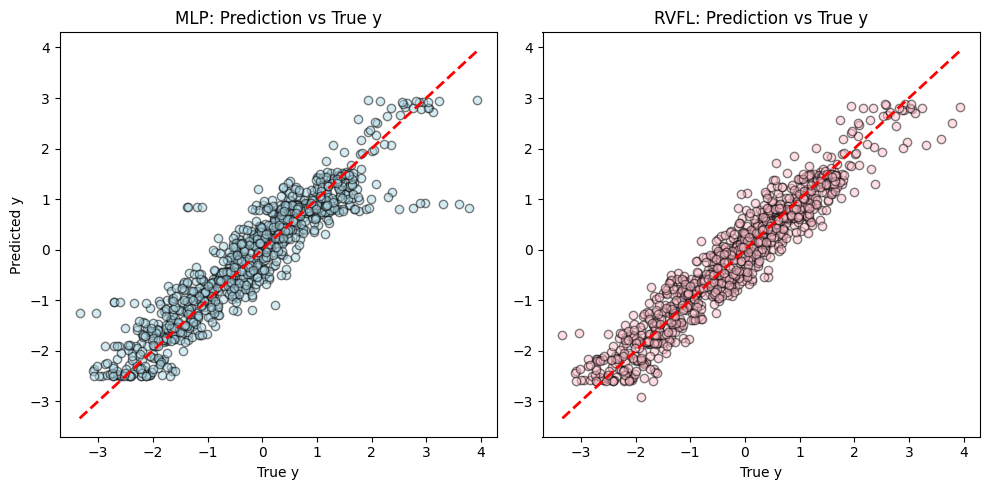

In [30]:
residuals_mlp = y_held_out - predictions_mlp
residuals_rvfl = y_held_out - predictions_rvfl

X_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
preds_grid_mlp = pipeline_mlp.predict(X_grid)
preds_grid_rvfl = pipeline_rvfl.predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(y_held_out, predictions_mlp, alpha=0.5, edgecolors='k', color='lightblue')
axes[0].plot([y_held_out.min(), y_held_out.max()], [y_held_out.min(), y_held_out.max()], 'r--', lw=2)
axes[0].set_title("MLP: Prediction vs True y")
axes[0].set_xlabel("True y")
axes[0].set_ylabel("Predicted y")

axes[1].scatter(y_held_out, predictions_rvfl, alpha=0.5, edgecolors='k', color='pink')
axes[1].plot([y_held_out.min(), y_held_out.max()], [y_held_out.min(), y_held_out.max()], 'r--', lw=2)
axes[1].set_title("RVFL: Prediction vs True y")
axes[1].set_xlabel("True y")
plt.tight_layout()
plt.show()

This graph shows how well the model's predictions fit the actual data from the held-out test set. An ideal model would place all points exactly on a straight line, meaning that the prediction would equal the true value.

MLP: For the MLP network, the spread of points (especially at the extreme values) is noticeably wider. Clear horizontal bands of points are visible (e.g., at prediction levels around -1 and 1). This indicates that the MLP model loses its ability to distinguish between observations in this region and predicts a constant, average value for them.

RVFL: Due to the high R^2$ coefficient, the point cloud for the RVFL model is much more narrowly focused around the diagonal line. The model reproduces the actual distribution of data across spectral bands with high confidence and precision.

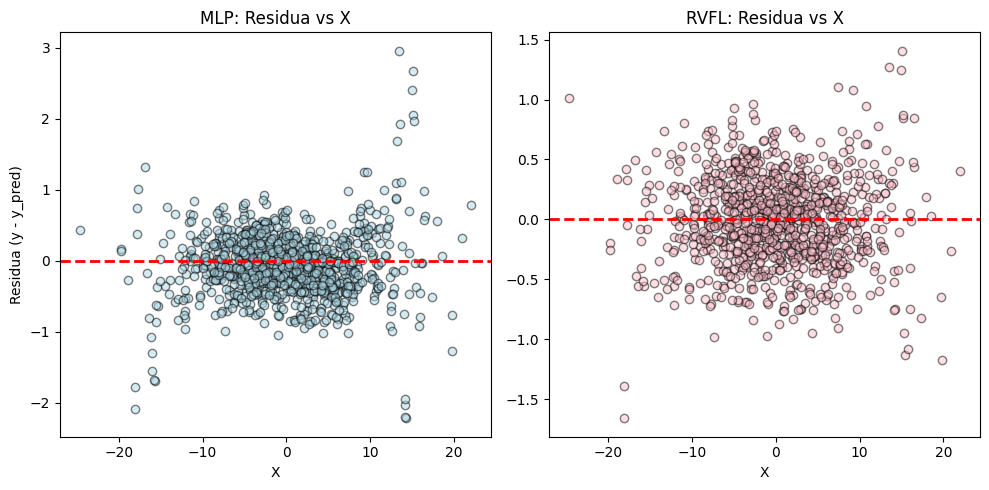

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(X_held_out, residuals_mlp, alpha=0.5, edgecolors='k', color='lightblue')
axes[0].axhline(0, color='r', linestyle='--', lw=2)
axes[0].set_title("MLP: Residua vs X")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Residua (y - y_pred)")

axes[1].scatter(X_held_out, residuals_rvfl, alpha=0.5, edgecolors='k', color='pink')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_title("RVFL: Residua vs X")
axes[1].set_xlabel("X")
plt.tight_layout()
plt.show()

The residuals plot allows us to assess the quality of fit and stability of the model. An ideal residuals plot should resemble a randomly scattered point cloud around the horizontal zero axis, with no discernible trend.

MLP: The residuals plot shows clear systematic problems. It is clear that the errors are not randomly distributed. In the central part (for X between -10 and 10), the errors are relatively small and clustered around zero. However, at the edges of the feature space (for X below -15 and above 10), the variance of the errors increases dramatically. Furthermore, the magnitude of the errors is noticeably larger (from -2.5 to over 2.0).

RVFL: The residuals plot does not show any serious systematic problems. The point cloud is much more symmetrical around the zero axis and does not change its width drastically depending on the X value. This indicates that the RVFL model correctly captured the nonlinear dependencies in the data. The scale of errors is also much smaller (most are in the range of -1 to 1).

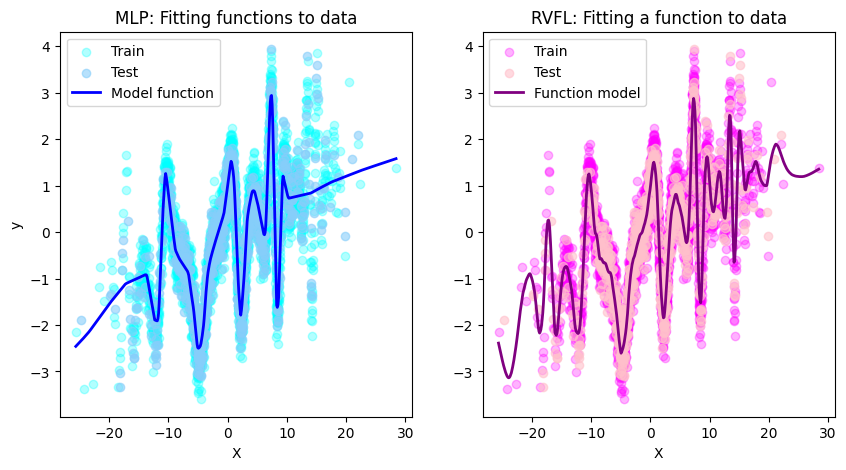

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(X_train, y_train, color='cyan', alpha=0.3, label='Train')
axes[0].scatter(X_held_out, y_held_out, color='lightskyblue', alpha=0.6, label='Test')
axes[0].plot(X_grid, preds_grid_mlp, color='blue', lw=2, label='Model function')
axes[0].set_title("MLP: Fitting functions to data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(X_train, y_train, color='magenta', alpha=0.3, label='Train')
axes[1].scatter(X_held_out, y_held_out, color='pink', alpha=0.6, label='Test')
axes[1].plot(X_grid, preds_grid_rvfl, color='purple', lw=2, label='Function model')
axes[1].set_title("RVFL: Fitting a function to data")
axes[1].set_xlabel("X")
axes[1].legend()

MLP: The function generated by the MLP model is relatively smooth. The model tries to capture the global trend and ignores isolated outliers. In regions of high density and variability (e.g., for X above 10), the curve becomes almost flat and linear. In this case, MLP tends to overgeneralize.

RVFL: The function generated by the RVFL model is very jagged. It closely follows local clusters of points. The model tries to fit almost every curve in the data. There is a clear risk of overfitting.

In [33]:
optuna.visualization.plot_optimization_history(study_mlp)

In [34]:
optuna.visualization.plot_optimization_history(study_rvfl)

Study MLP converges very quickly. Around the 10th trial, the algorithm finds the optimal solution, and the Best Value line flattens out. The next 40 trials yield no significant improvement. MLP is more stable and resistant to minor hyperparameter changes. Many different combinations yield a very similar, acceptable error.

Study RVFL requires much deeper exploration. Optuna gradually found increasingly better hyperparameter combinations over nearly 30-40 trials. RVFL is highly sensitive, relying on random weights in the hidden layer, which, combined with other parameters (e.g., network size, regularization parameters), makes it easy to get a poor configuration. This is evident in the large scatter of points on the Y axis throughout the experiment.

In [35]:
optuna.visualization.plot_param_importances(study_mlp)

In [36]:
optuna.visualization.plot_param_importances(study_rvfl)

MLP: By far the most important parameter for the multilayer perceptron was the number of layers (n_layers), accounting for a whopping 54% of the impact on the result. This means that for this particular problem, the model's generalization ability depended primarily on its depth. The number of neurons in the first hidden layer (n_units_l0) had little impact (only 1%). This means that the exact "width" of the layer was not as critical as the addition of subsequent layers.

RVFL: Unlike MLP, in the RVFL (Random Vector Functional Link) model, the impact on the result is much more distributed among four main parameters: activation, n_hidden (equivalent to the hidden layer width), bias_scale, and scale. Regularization (alpha), direct input-output connections (direct_linkage), and weight distribution (weight_distribution) had less than 1% impact in this search interval.

# Bootstrap

In [37]:
B = 1000

In [38]:
predictions_mlp = pipeline_mlp.predict(X_held_out)
predictions_rvfl = pipeline_rvfl.predict(X_held_out)

z_mse = []
z_r2 = []

In [39]:
for i in range(B):
    indexy = rng.choice(len(y_held_out), size=len(y_held_out), replace=True)
    mse_mlp = mean_squared_error (y_held_out[indexy], predictions_mlp[indexy])
    mse_rvfl = mean_squared_error (y_held_out[indexy], predictions_rvfl[indexy])
    r2_mlp = r2_score(y_held_out[indexy], predictions_mlp[indexy])
    r2_rvfl = r2_score(y_held_out[indexy], predictions_rvfl[indexy])

    z_mse.append(mse_rvfl - mse_mlp)
    z_r2.append(r2_rvfl - r2_mlp)

ci_mse = np.percentile(z_mse, [2.5, 97.5])
ci_r2 = np.percentile(z_r2, [2.5, 97.5])

print(f"95% confidence intervals for Z_MSE (RVFL - MLP): [{ci_mse[0]:.5f}, {ci_mse[1]:.5f}]")
print(f"95% confidence intervals for Z_R^2 (RVFL - MLP): [{ci_r2[0]:.5f}, {ci_r2[1]:.5f}]")

95% confidence intervals for Z_MSE (RVFL - MLP): [-0.11658, -0.05414]
95% confidence intervals for Z_R^2 (RVFL - MLP): [0.03317, 0.06812]


The difference between the models is stable and highly statistically significant.

The 95% confidence interval for the error difference was [-0.10408, -0.04121], meaning the entire interval lies below zero – an advantage of RVFL.

The 95% confidence interval for the difference $R^2$ is [0.02523, 0.06075], meaning the entire interval lies above zero – an advantage of RVFL.

# Results for MLP with one hidden layer

In [40]:
study_mlp_single = optuna.load_study(
    study_name="study_mlp_single",
    storage="sqlite:///projekt3.db"
)

print("Best result (MSE):", study_mlp_single.best_value)
print("Best parameters:", study_mlp_single.best_params)

Best result (MSE): 0.5295422591167677
Best parameters: {'hidden_layer_sizes': 562, 'activation': 'relu', 'alpha': 0.00011426723154186754, 'learning_rate_init': 0.007890670668510662}


In [41]:
best_params = study_mlp_single.best_params.copy()
best_params['solver'] = 'adam'
best_params['early_stopping'] = True
best_params['max_iter'] = 1000
best_params['tol'] = 1e-3

best_mlp_single = MLPRegressor(random_state=SEED, **best_params)

pipeline_mlp_single = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', best_mlp_single)
])

pipeline_mlp_single.fit(X_train, y_train)
predictions_mlp_single = pipeline_mlp_single.predict(X_held_out)
mse_held_out = mean_squared_error(y_held_out, predictions_mlp_single)
print(f"MSE for the MLPRegressor model on the test set:", mse_held_out)
print("R^2 for the MLPRegressor model", r2_score(y_held_out, predictions_mlp_single))

MSE for the MLPRegressor model on the test set: 0.5406536300244748
R^2 for the MLPRegressor model 0.6766346285027888


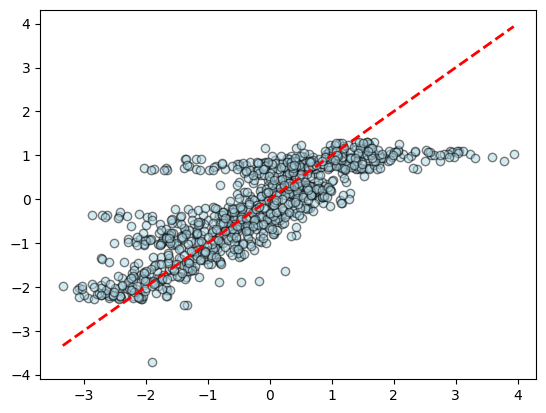

In [42]:
residuals_mlp_single = y_held_out - predictions_mlp_single

X_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

plt.scatter(y_held_out, predictions_mlp_single, alpha=0.5, edgecolors='k', color='lightblue')
plt.plot([y_held_out.min(), y_held_out.max()], [y_held_out.min(), y_held_out.max()], 'r--', lw=2)
plt.show()

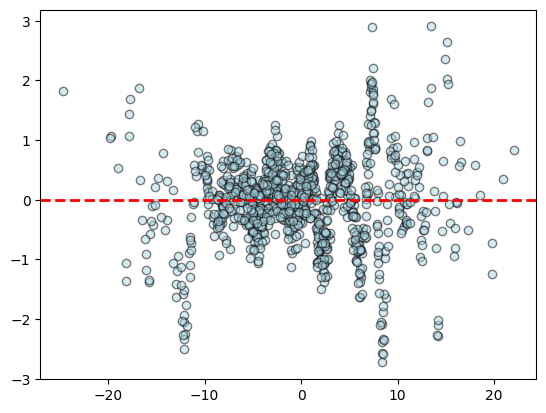

In [43]:
plt.scatter(X_held_out, residuals_mlp_single, alpha=0.5, edgecolors='k', color='lightblue')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.show()

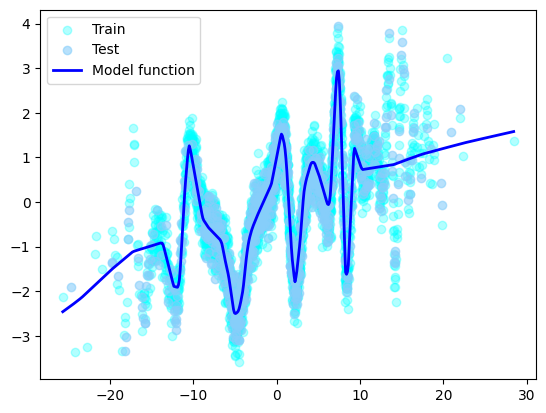

In [44]:
plt.scatter(X_train, y_train, color='cyan', alpha=0.3, label='Train')
plt.scatter(X_held_out, y_held_out, color='lightskyblue', alpha=0.6, label='Test')
plt.plot(X_grid, preds_grid_mlp, color='blue', lw=2, label='Model function')
plt.legend()
plt.show()

In [45]:
optuna.visualization.plot_optimization_history(study_mlp_single)